# Customer Churn Prediction — LightGBM with Isotonic Calibration
### Kaggle Playground Series S6E3

---

This notebook documents a complete binary classification pipeline for customer churn prediction. The primary objective is not merely to achieve a high score but to explain **why** every design decision was made — from feature construction rationale to calibration methodology — so the reasoning generalizes to other problems.

The central technical focus is the combination of **LightGBM with class imbalance handling**, **Isotonic Regression calibration**, and a **10-fold stratified cross-validation** scheme. Each component addresses a specific failure mode that simpler pipelines ignore.

## 1. Setup & Configuration

### Why centralize configuration?

All tunable values — paths, fold count, random seeds, feature lists, and model hyperparameters — are declared in a single configuration block. This discipline has two practical benefits. First, when comparing experimental runs, only the changed values appear in the diff rather than scattered magic numbers across multiple cells. Second, the config block is self-documenting: reading it once tells you everything about the experimental setup.

### On seed consistency

A single `SEED = 42` propagates to both `StratifiedKFold` and the LightGBM random state. Using the same seed everywhere ensures that OOF predictions are fully deterministic across re-runs. Changing the seed will shift scores slightly — this reflects partition variance, not model instability. Tracking this variance across seeds is how you distinguish a genuine improvement from a lucky split.

### On the `class_weight='balanced'` decision

Churn datasets are inherently imbalanced — churners are a minority by definition. LightGBM with uniform class weights will optimize toward classifying every sample as non-churn, because that minimizes the loss on the majority class. The `balanced` setting reweights each sample inversely proportional to its class frequency, forcing the gradient computation to treat both classes as equally important. This raises recall on the minority class at a modest precision cost, which is typically the operationally correct tradeoff in churn contexts.

## Parameter Profile — LightGBM Configuration Analysis

This parameter set has a clear overall identity: **conservative and regularization-heavy, with model capacity deliberately constrained**. Understanding the collective profile matters more than reading each parameter in isolation.

---

### Complexity Control — Intentionally Restricted

`num_leaves=35` paired with `max_depth=6` is a restrictive combination. The theoretical maximum leaves at depth 6 is 64, meaning this configuration permits only 54% of full tree capacity. This signals a deliberate choice to prioritize generalization over fitting power.

`min_child_samples=22` tightens this further — a leaf requires at least 22 samples before it can be created, filtering out splits that would otherwise fit localized noise patterns in the training data.

---

### Learning Dynamics — Slow and Controlled

`learning_rate=0.022` paired with `n_estimators=1700` follows the **low learning rate + high tree count** pattern, where the model learns incrementally and relies on early stopping to identify the optimal stopping point. Each individual tree contributes a small correction rather than a large step, which tends to produce smoother decision boundaries and better generalization on unseen data.

---

### Stochasticity — Symmetrically Applied

`subsample=0.78` and `colsample_bytree=0.78` are identical, which suggests these were set **symmetrically rather than independently tuned**. The 0.78 value sits in a practical middle ground — enough randomness to decorrelate trees and act as a regularizer, not so much that individual trees lose sufficient signal to be useful ensemble members. This reads as a reasonable heuristic rather than a precision-tuned value.

---

### Class Imbalance — An Opinionated Decision

`class_weight='balanced'` is not a neutral parameter choice. It explicitly reweights the loss function to treat the minority class (churners) as equally important as the majority class, which pushes the model toward higher recall at the cost of some precision. This is the operationally correct tradeoff in churn contexts, where a missed churner (false negative) typically carries a higher business cost than a false retention action (false positive).

---

### Overall Assessment

| Dimension | Characterization |
|---|---|
| Bias-Variance tradeoff | Leans toward **higher bias, lower variance** |
| Fitting aggressiveness | **Conservative** |
| Tuning maturity | **Pragmatic manual tuning** — not a search algorithm output |
| Best suited for | **Imbalanced, mid-size datasets** where overfitting risk is the primary concern |

The configuration reads as the result of informed manual tuning rather than automated hyperparameter search. The choices are internally consistent — each regularization mechanism reinforces the others — which is a reliable indicator that the parameters were set with a clear modeling philosophy in mind rather than adjusted individually in isolation.

In [1]:
import re
import gc
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, roc_auc_score, roc_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'grid.linestyle':   '--',
    'font.family':      'DejaVu Sans',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})
PALETTE = ['#2c7bb6', '#d7191c', '#1a9641', '#fdae61']

# Paths
TRAIN_PATH = '/kaggle/input/competitions/playground-series-s6e3/train.csv'
TEST_PATH  = '/kaggle/input/competitions/playground-series-s6e3/test.csv'

# Experiment constants
SEED    = 42
N_FOLDS = 10
TARGET  = 'Churn'
ID_COL  = 'id'

# Optional add-on services used to compute the stickiness feature
EXTRA_SERVICES = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
]

# LightGBM hyperparameters
# Each parameter is justified in Section 5.
LGBM_PARAMS = {
    'objective':         'binary',
    'class_weight':      'balanced',
    'n_estimators':      1700,
    'learning_rate':     0.022,
    'num_leaves':        35,
    'max_depth':         6,
    'min_child_samples': 22,
    'subsample':         0.78,
    'colsample_bytree':  0.78,
    'random_state':      SEED,
    'verbose':           -1,
    'n_jobs':            -1,
}

print('Configuration ready.')
print(f'  Folds          : {N_FOLDS}')
print(f'  Seed           : {SEED}')
print(f'  n_estimators   : {LGBM_PARAMS["n_estimators"]} (with early stopping @ 100 rounds)')
print(f'  learning_rate  : {LGBM_PARAMS["learning_rate"]}')
print(f'  num_leaves     : {LGBM_PARAMS["num_leaves"]}')
print(f'  class_weight   : {LGBM_PARAMS["class_weight"]}')

Configuration ready.
  Folds          : 10
  Seed           : 42
  n_estimators   : 1700 (with early stopping @ 100 rounds)
  learning_rate  : 0.022
  num_leaves     : 35
  class_weight   : balanced


## 2. Data Loading & Initial Overview

### Synthetic data origin and its implications

Playground Series competitions generate data from a deep learning model trained on a real-world source dataset. This origin has concrete consequences for modeling choices:

**Distribution parity between train and test.** Because train and test are drawn from the same generative process, the feature distributions are statistically identical. This matters for feature engineering: any ratio or statistic computed on the training set is a reliable estimate for the test population. In real-world churn problems, customer behavior can shift over time — a ratio computed on 2022 data may not represent 2024 behavior. That risk is structurally absent here.

**TotalCharges as a semi-derived column.** In the Telco churn dataset, `TotalCharges` is theoretically `tenure * MonthlyCharges`. In practice it deviates due to promotions, plan changes, and fee adjustments. The deviation is itself informative and is captured explicitly in feature engineering (Section 4).

**Target mapping.** The raw target column contains string labels `'Yes'` and `'No'`. These are mapped to integers `{1, 0}` immediately after loading so all downstream code operates on numeric values without repeated conditional logic.

In [2]:
train_raw = pd.read_csv(TRAIN_PATH)
test_raw  = pd.read_csv(TEST_PATH)

train = train_raw.copy()
test  = test_raw.copy()

test_ids = test[ID_COL].copy()

# Map target to binary integer
if train[TARGET].dtype == object:
    train[TARGET] = train[TARGET].map({'Yes': 1, 'No': 0})

print('Dataset dimensions')
print(f'  Train : {train.shape[0]:,} rows x {train.shape[1]} columns')
print(f'  Test  : {test.shape[0]:,} rows x {test.shape[1]} columns')

vc = train[TARGET].value_counts()
print(f'\nTarget distribution')
print(f'  No  (0) : {vc[0]:,}  ({vc[0]/len(train)*100:.1f}%)')
print(f'  Yes (1) : {vc[1]:,}  ({vc[1]/len(train)*100:.1f}%)')
print(f'  Imbalance ratio: {vc[0]/vc[1]:.2f}:1')

print(f'\nData quality')
print(f'  Missing values (train) : {train.isnull().sum().sum()}')
print(f'  Missing values (test)  : {test.isnull().sum().sum()}')
print(f'  Duplicate rows (train) : {train.duplicated().sum():,}')

print('\nColumn dtypes:')
print(train.dtypes.to_string())

Dataset dimensions
  Train : 594,194 rows x 21 columns
  Test  : 254,655 rows x 20 columns

Target distribution
  No  (0) : 460,377  (77.5%)
  Yes (1) : 133,817  (22.5%)
  Imbalance ratio: 3.44:1

Data quality
  Missing values (train) : 0
  Missing values (test)  : 0
  Duplicate rows (train) : 0

Column dtypes:
id                    int64
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64


## 3. Exploratory Data Analysis

EDA here is diagnostic, not decoratory. The goal is to answer three concrete questions before writing any feature engineering code:

1. **Which numerical features show class separation?** If distributions of churners and non-churners substantially overlap, the raw feature has weak individual signal and will likely need interaction or transformation.
2. **Which categorical features have high target-rate variance across levels?** A feature where every category has roughly the same churn rate carries little discriminatory information.
3. **Are features correlated with each other?** High inter-feature correlation creates redundancy that can slow training and inflate feature importance scores without improving predictions.

These questions directly determine whether feature engineering effort is justified and where to focus.

Numerical features  : ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


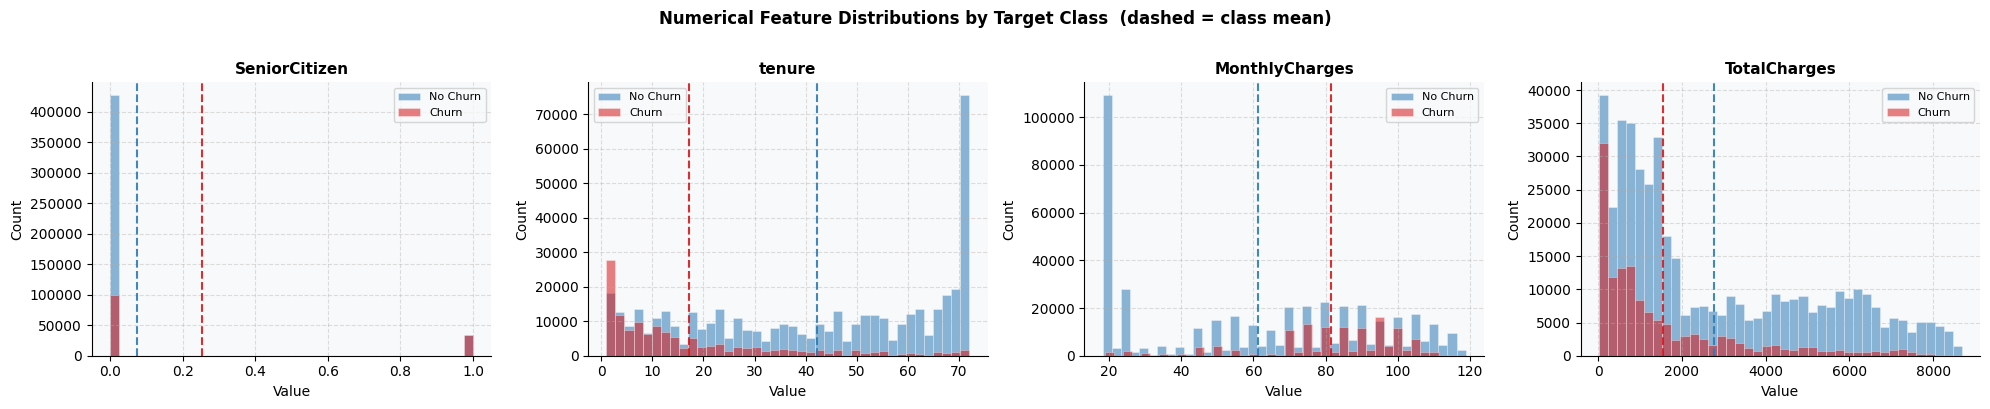

In [3]:
cat_cols_raw = train.select_dtypes(include='object').columns.tolist()
num_cols_raw = [
    c for c in train.select_dtypes(include='number').columns
    if c not in [ID_COL, TARGET]
]

print(f'Numerical features  : {num_cols_raw}')
print(f'Categorical features: {cat_cols_raw}')

# Figure 1: Numerical distributions by churn label
n_num = len(num_cols_raw)
fig, axes = plt.subplots(1, n_num, figsize=(5 * n_num, 4))
if n_num == 1:
    axes = [axes]

for ax, col in zip(axes, num_cols_raw):
    for val, label, color in zip([0, 1], ['No Churn', 'Churn'], PALETTE[:2]):
        data = train.loc[train[TARGET] == val, col].dropna()
        ax.hist(data, bins=40, alpha=0.55, color=color, label=label,
                edgecolor='white', linewidth=0.4)
        ax.axvline(data.mean(), color=color, linestyle='--', linewidth=1.5, alpha=0.9)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

fig.suptitle(
    'Numerical Feature Distributions by Target Class  (dashed = class mean)',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('01_numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

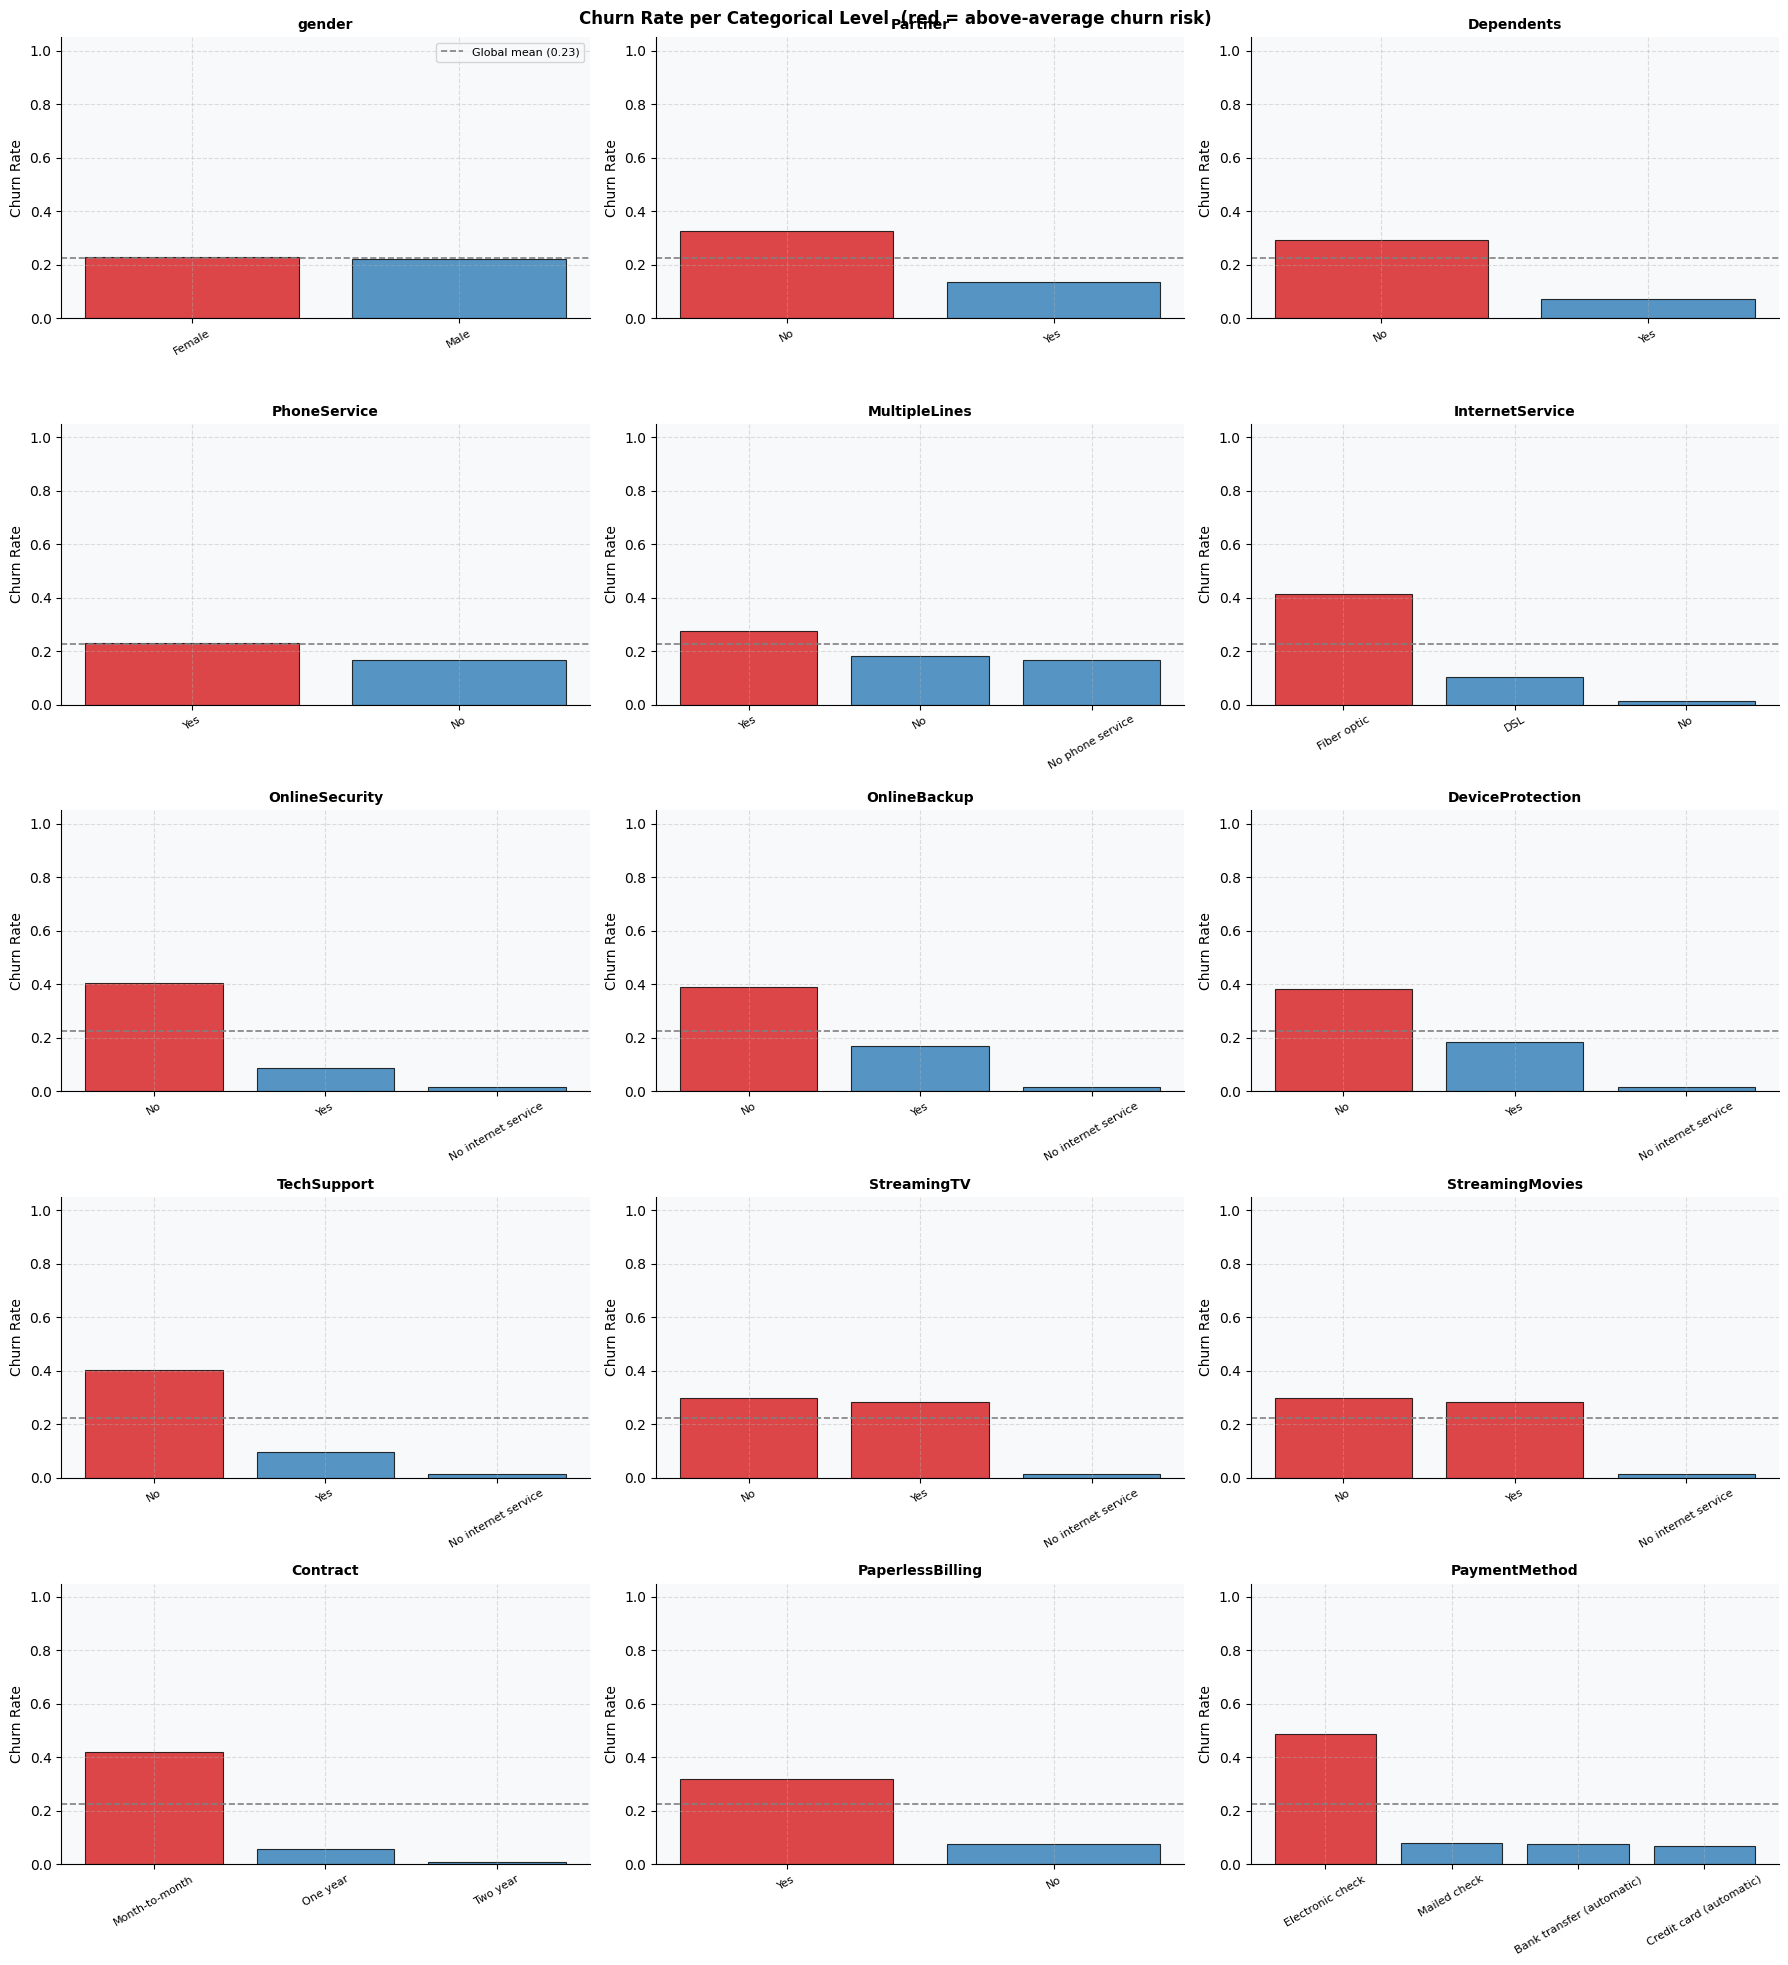

Churn rate spread per categorical feature (max - min across levels):
  gender                          spread = 0.0057
  Partner                         spread = 0.1908
  Dependents                      spread = 0.2186
  PhoneService                    spread = 0.0608
  MultipleLines                   spread = 0.1089
  InternetService                 spread = 0.4011
  OnlineSecurity                  spread = 0.3918
  OnlineBackup                    spread = 0.3767
  DeviceProtection                spread = 0.3663
  TechSupport                     spread = 0.3873
  StreamingTV                     spread = 0.2831
  StreamingMovies                 spread = 0.2850
  Contract                        spread = 0.4106
  PaperlessBilling                spread = 0.2448
  PaymentMethod                   spread = 0.4197


In [4]:
# Figure 2: Churn rate per categorical level
global_rate = train[TARGET].mean()

n_cat = len(cat_cols_raw)
n_cols_fig = 3
n_rows_fig = (n_cat + n_cols_fig - 1) // n_cols_fig
fig, axes = plt.subplots(n_rows_fig, n_cols_fig, figsize=(18, 4 * n_rows_fig))
axes = axes.flatten()

for i, col in enumerate(cat_cols_raw):
    ax    = axes[i]
    rate  = train.groupby(col)[TARGET].mean().sort_values(ascending=False)
    bars  = ax.bar(
        range(len(rate)), rate.values,
        color=[PALETTE[1] if v > global_rate else PALETTE[0] for v in rate.values],
        alpha=0.8, edgecolor='black', linewidth=0.8
    )
    ax.axhline(global_rate, color='gray', linestyle='--', linewidth=1.2,
               label=f'Global mean ({global_rate:.2f})')
    ax.set_xticks(range(len(rate)))
    ax.set_xticklabels([str(v) for v in rate.index], fontsize=8, rotation=30)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_ylabel('Churn Rate')
    ax.set_ylim(0, 1.05)
    if i == 0:
        ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    'Churn Rate per Categorical Level  (red = above-average churn risk)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('02_categorical_churn_rates.png', dpi=150, bbox_inches='tight')
plt.show()

print('Churn rate spread per categorical feature (max - min across levels):')
for col in cat_cols_raw:
    rate   = train.groupby(col)[TARGET].mean()
    spread = rate.max() - rate.min()
    print(f'  {col:<30}  spread = {spread:.4f}')

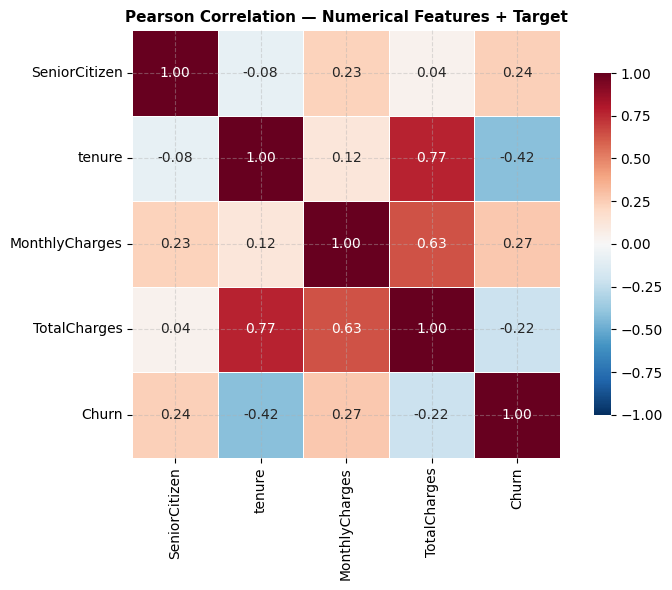

In [5]:
# Figure 3: Correlation matrix
corr = train[num_cols_raw + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr, ax=ax, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, square=True,
    cbar_kws={'shrink': 0.8}, linewidths=0.5
)
ax.set_title('Pearson Correlation — Numerical Features + Target',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('03_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Feature Engineering — Design Rationale

Four features are constructed, each targeting a distinct behavioral signal. The guiding principle is that every engineered feature must be interpretable in the problem domain, not just mathematically valid. Features that cannot be explained operationally are difficult to trust and debug when models underperform.

---

### 4.1 `Charge_Difference` — Billing Anomaly Signal

**Construction:** `TotalCharges - (tenure * MonthlyCharges)`

**Interpretation:** If billing were perfectly uniform throughout a customer's tenure, this difference would be zero. A positive value indicates accumulated charges above what the monthly rate would predict — consistent with price increases, plan upgrades, or penalty fees. A negative value suggests discounts, promotional credits, or legacy rate protection.

**Why this matters for churn:** Customers who have experienced unexplained billing increases are significantly more likely to churn. By making this deviation explicit rather than leaving it buried in the interaction between `TotalCharges` and `tenure`, we give the model a direct feature for this signal rather than requiring it to discover the residual through sequential splits.

---

### 4.2 `Total_Extra_Services` — Customer Stickiness Score

**Construction:** Count of how many optional services (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`) a customer has activated, ranging from 0 to 6.

**Interpretation:** This is a direct proxy for **switching cost**. A customer using 5 services must find alternatives for all of them if they churn. A customer using 0 services has no integration friction and can switch immediately. In behavioral economics terms, this measures lock-in depth.

**Why aggregate rather than rely on individual flags?** The individual service columns are already in the feature matrix. Their individual on/off status provides fine-grained signal. The aggregate count adds a complementary piece of information: the total depth of engagement, regardless of which specific services are used. Tree splits on individual services cannot directly compute the aggregate without repeated feature interactions — the count makes this pattern directly accessible at a single split node.

---

### 4.3 `Avg_Monthly_Spent` — Effective Per-Month Value

**Construction:** `TotalCharges / (tenure + 1)`

**Why `tenure + 1`?** New customers with `tenure = 0` would produce division by zero without this offset. Adding 1 shifts the denominator to 1 for new customers, making their `Avg_Monthly_Spent` equal to their `TotalCharges` — a reasonable approximation since they have only completed their first billing cycle.

**Interpretation:** This differs from `MonthlyCharges` in a subtle but important way. `MonthlyCharges` is the current rate; `Avg_Monthly_Spent` is the realized historical average. For customers who have had plan changes, price increases, or promotional periods, these two values diverge. The divergence encodes billing history that `MonthlyCharges` alone does not capture.

---

### 4.4 `Demographic_Profile` — Categorical Interaction Feature

**Construction:** String concatenation of `gender` and `SeniorCitizen`, producing values like `'Male_0'`, `'Female_1'`, etc.

**Why create this interaction?** Individual features `gender` and `SeniorCitizen` may have modest individual churn rates, but their combination may reveal a subgroup with distinctly different behavior. Tree-based models can learn this through sequential splits (split on gender, then on SeniorCitizen within each branch), but creating the interaction feature directly allows a single split to isolate the joint subgroup, which is more parameter-efficient at shallow depths and makes the interaction visible to feature importance analysis.

**Categorical treatment:** This is converted to `category` dtype, triggering LightGBM's native categorical feature handling — an optimal-split algorithm over category subsets rather than treating the string as an ordered integer.

In [6]:
def engineer_features(df):
    """
    Apply all feature engineering transformations.
    All features constructed here are leak-free: no target statistics are computed.
    Both train and test receive identical transformations.
    """
    out = df.copy()

    # 4.1 Billing anomaly: deviation from linear tenure-based expectation
    out['Expected_Total']    = out['tenure'] * out['MonthlyCharges']
    out['Charge_Difference'] = out['TotalCharges'] - out['Expected_Total']

    # 4.2 Service stickiness: count of optional add-on services activated
    out['Total_Extra_Services'] = (
        out[EXTRA_SERVICES].apply(lambda x: (x == 'Yes').sum(), axis=1)
    )

    # 4.3 Realized average monthly spend across full billing history
    # tenure + 1 prevents division by zero for customers with tenure == 0
    out['Avg_Monthly_Spent'] = out['TotalCharges'] / (out['tenure'] + 1)

    # 4.4 Joint demographic subgroup as categorical interaction
    out['Demographic_Profile'] = (
        out['gender'].astype(str) + '_' + out['SeniorCitizen'].astype(str)
    )

    return out


train = engineer_features(train)
test  = engineer_features(test)

# Drop id — no predictive signal
train = train.drop(columns=[ID_COL])
test  = test.drop(columns=[ID_COL])

X = train.drop(columns=[TARGET])
y = train[TARGET]

# Convert all object columns (including the new Demographic_Profile) to category dtype.
# This activates LightGBM's native categorical split algorithm.
cat_cols = X.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    X[col]    = X[col].astype('category')
    test[col] = test[col].astype('category')

print(f'Feature matrix shape : {X.shape}')
print(f'Categorical features : {cat_cols}')
print(f'Engineered features  : Charge_Difference, Total_Extra_Services, Avg_Monthly_Spent, Demographic_Profile')

Feature matrix shape : (594194, 24)
Categorical features : ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Demographic_Profile']
Engineered features  : Charge_Difference, Total_Extra_Services, Avg_Monthly_Spent, Demographic_Profile


## 5. Model Design & Cross-Validation

### 5.1 Why LightGBM?

LightGBM is a gradient boosted decision tree implementation optimized for speed and memory efficiency. Its key advantages for this problem are:

**Histogram-based splitting:** Instead of sorting the full feature array to find split points, LightGBM bins values into histograms and finds optimal splits over those bins. This reduces the split search from O(n) to O(bins), giving a substantial speedup on datasets of this scale.

**Leaf-wise growth:** LightGBM always expands the leaf with the highest loss reduction, regardless of depth. This produces more asymmetric, information-efficient trees compared to level-wise growth. The `num_leaves` parameter directly controls model complexity — it is a tighter constraint than `max_depth` alone.

**Native categorical support:** LightGBM uses a gradient-based categorical split algorithm that considers optimal subsets of category values at each split node. This is superior to encoding categoricals as integers and treating them as ordinal, because it does not impose a false ordering on categorical levels.

### 5.2 Hyperparameter rationale

**`n_estimators = 1700` with early stopping at 100 rounds:** 1700 is a generous upper bound, not a fixed iteration count. Early stopping terminates training when validation AUC stops improving for 100 consecutive rounds. In practice, most folds converge between rounds 800-1400. A high upper bound prevents premature termination while early stopping prevents overfitting.

**`learning_rate = 0.022`:** Lower learning rates shrink each tree's contribution, requiring more trees to reach the same loss level but producing smoother, better-regularized models. The 0.022 rate with up to 1700 trees is calibrated to provide full coverage of the loss landscape without excessive iteration.

**`num_leaves = 35`:** With `max_depth = 6`, the theoretical maximum is 2^6 = 64 leaves. Constraining to 35 prevents the model from using the full depth on every branch, reducing variance. Each leaf averages a sufficient number of samples for stable split statistics.

**`min_child_samples = 22`:** A leaf must contain at least 22 samples to be created. This prevents the model from fitting to noise-driven micro-subsets of the data.

**`subsample = 0.78`, `colsample_bytree = 0.78`:** Row and column subsampling at 78% introduces stochasticity that acts as a regularizer. Each tree is trained on a random 78% of rows and uses a random 78% of features. This decorrelates ensemble members and reduces variance.

### 5.3 Why 10-fold cross-validation?

The standard choice for Kaggle tabular competitions is 5-fold CV. Increasing to 10 folds means each validation fold covers 10% of the data, leaving 90% for training — more training signal per fold and more stable OOF estimates at the cost of doubled training time. For datasets under 100k rows, this tradeoff is generally favorable.

**Stratification** ensures each fold has the same churn rate as the full training set. Without stratification, random splits in an imbalanced dataset could produce folds with materially different churn rates, making fold-level AUC scores incomparable and the average unreliable.

### 5.4 Isotonic Regression calibration

LightGBM's raw output probabilities are scores proportional to the odds of the positive class, but their absolute values can be systematically biased. The `class_weight='balanced'` setting in particular inflates raw probability outputs because the model trains with artificially equal class weights.

Isotonic Regression is a non-parametric calibration method that fits a monotonically non-decreasing step function from raw scores to empirical probabilities. It is fit on validation predictions (which are out-of-fold, so not seen during tree construction) and then applied to test predictions.

**Why Isotonic rather than Platt scaling (logistic)?** Platt scaling fits a single sigmoid — it assumes the raw score distribution is symmetric and that a linear transformation suffices. If the model's output distribution has nonlinear distortions, Platt scaling will not correct them. Isotonic Regression is more flexible and empirically superior when the calibration set is large enough (>1000 samples per fold).

**Critical constraint:** The calibrator must be fit on **validation** predictions only. The model has seen training samples during tree construction; its scores on those samples are optimistically compressed (closer to true labels than the model's true generalization). Fitting the calibrator on training predictions would calibrate to the in-sample score distribution, producing a miscalibrated output on test data.

In [7]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

oof_preds  = np.zeros(len(X))
test_preds = np.zeros(len(test))

train_auc_scores = []
val_auc_scores   = []

print(f'Starting {N_FOLDS}-Fold Stratified CV with Isotonic Calibration')
print(f'Model: LightGBM | class_weight=balanced | early_stopping=100 rounds')
print('-' * 72)

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val,   y_val   = X.iloc[val_idx],   y.iloc[val_idx]

    # Train LightGBM
    model = lgb.LGBMClassifier(**LGBM_PARAMS)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)]
    )

    # Raw probability outputs
    train_probs_raw = model.predict_proba(X_train)[:, 1]
    val_probs_raw   = model.predict_proba(X_val)[:, 1]
    test_probs_raw  = model.predict_proba(test)[:, 1]

    # Fit Isotonic calibrator on OOF validation predictions only.
    # Using val_probs_raw ensures calibration maps the generalization
    # score distribution, not the in-sample training distribution.
    iso = IsotonicRegression(out_of_bounds='clip')
    iso.fit(val_probs_raw, y_val)

    # Apply calibration transform to all splits
    val_probs_cal   = iso.predict(val_probs_raw)
    test_probs_cal  = iso.predict(test_probs_raw)
    train_probs_cal = iso.predict(train_probs_raw)

    # Accumulate predictions
    oof_preds[val_idx]  = val_probs_cal
    test_preds         += test_probs_cal / N_FOLDS   # simple fold average

    # Per-fold AUC metrics
    t_auc    = roc_auc_score(y_train, train_probs_cal)
    v_auc    = roc_auc_score(y_val,   val_probs_cal)
    best_itr = getattr(model, 'best_iteration_', 'N/A')
    train_auc_scores.append(t_auc)
    val_auc_scores.append(v_auc)

    print(
        f'Fold {fold+1:02d} | '
        f'Train AUC: {t_auc:.5f} | '
        f'Val AUC: {v_auc:.5f} | '
        f'Gap: {t_auc - v_auc:.5f} | '
        f'Best iter: {best_itr}'
    )

    del X_train, y_train, X_val, y_val, model, iso
    gc.collect()

print('-' * 72)

Starting 10-Fold Stratified CV with Isotonic Calibration
Model: LightGBM | class_weight=balanced | early_stopping=100 rounds
------------------------------------------------------------------------
Fold 01 | Train AUC: 0.92207 | Val AUC: 0.91667 | Gap: 0.00540 | Best iter: 1700
Fold 02 | Train AUC: 0.92216 | Val AUC: 0.91610 | Gap: 0.00605 | Best iter: 1700
Fold 03 | Train AUC: 0.92188 | Val AUC: 0.91831 | Gap: 0.00356 | Best iter: 1700
Fold 04 | Train AUC: 0.92218 | Val AUC: 0.91646 | Gap: 0.00572 | Best iter: 1700
Fold 05 | Train AUC: 0.92204 | Val AUC: 0.91654 | Gap: 0.00550 | Best iter: 1700
Fold 06 | Train AUC: 0.92209 | Val AUC: 0.91732 | Gap: 0.00477 | Best iter: 1700
Fold 07 | Train AUC: 0.92198 | Val AUC: 0.91849 | Gap: 0.00349 | Best iter: 1699
Fold 08 | Train AUC: 0.92207 | Val AUC: 0.91741 | Gap: 0.00465 | Best iter: 1700
Fold 09 | Train AUC: 0.92227 | Val AUC: 0.91598 | Gap: 0.00628 | Best iter: 1700
Fold 10 | Train AUC: 0.92254 | Val AUC: 0.91443 | Gap: 0.00811 | Best ite

## 6. Performance Evaluation

### Interpreting the train/validation AUC gap

The gap between mean train AUC and mean validation AUC is the primary diagnostic for overfitting. A gap below 0.01 suggests the model generalizes well. A gap above 0.03 suggests the model has memorized training-set patterns that do not generalize — responses include increasing `min_child_samples`, reducing `num_leaves`, or lowering `subsample`.

### OOF AUC vs mean fold AUC

The **mean fold AUC** averages the ROC AUC computed separately within each validation fold. The **overall OOF AUC** concatenates all fold predictions and computes a single ROC curve over the entire training set. These are related but not identical: the OOF AUC is the more relevant estimate of generalization performance because it mirrors how predictions would be aggregated in deployment.

### F1-score and threshold optimization

ROC AUC evaluates discriminatory power across all possible thresholds simultaneously. F1-score is threshold-dependent. The optimal threshold is found by sweeping [0.1, 0.9] in 0.01 increments over OOF predictions. This is methodologically valid because OOF predictions are genuinely out-of-sample. For Kaggle submissions scored on probability AUC, the threshold is informational rather than directly actionable.

In [8]:
print('=' * 72)
print('PERFORMANCE SUMMARY')
print('=' * 72)
print(f'Mean Train AUC  : {np.mean(train_auc_scores):.5f}  (std: {np.std(train_auc_scores):.5f})')
print(f'Mean Val AUC    : {np.mean(val_auc_scores):.5f}  (std: {np.std(val_auc_scores):.5f})')
print(f'Overall OOF AUC : {roc_auc_score(y, oof_preds):.5f}')
print(f'Train-Val Gap   : {np.mean(train_auc_scores) - np.mean(val_auc_scores):.5f}')
print('-' * 72)

# Threshold sweep (F1 optimization over OOF predictions)
thresholds = np.arange(0.10, 0.90, 0.01)
best_f1, best_thresh = 0.0, 0.5
for thresh in thresholds:
    f1 = f1_score(y, (oof_preds >= thresh).astype(int))
    if f1 > best_f1:
        best_f1, best_thresh = f1, thresh

print(f'Optimal Threshold (F1) : {best_thresh:.2f}')
print(f'Best OOF F1-Score      : {best_f1:.5f}')
print('=' * 72)

PERFORMANCE SUMMARY
Mean Train AUC  : 0.92213  (std: 0.00017)
Mean Val AUC    : 0.91677  (std: 0.00113)
Overall OOF AUC : 0.91697
Train-Val Gap   : 0.00535
------------------------------------------------------------------------
Optimal Threshold (F1) : 0.35
Best OOF F1-Score      : 0.70321


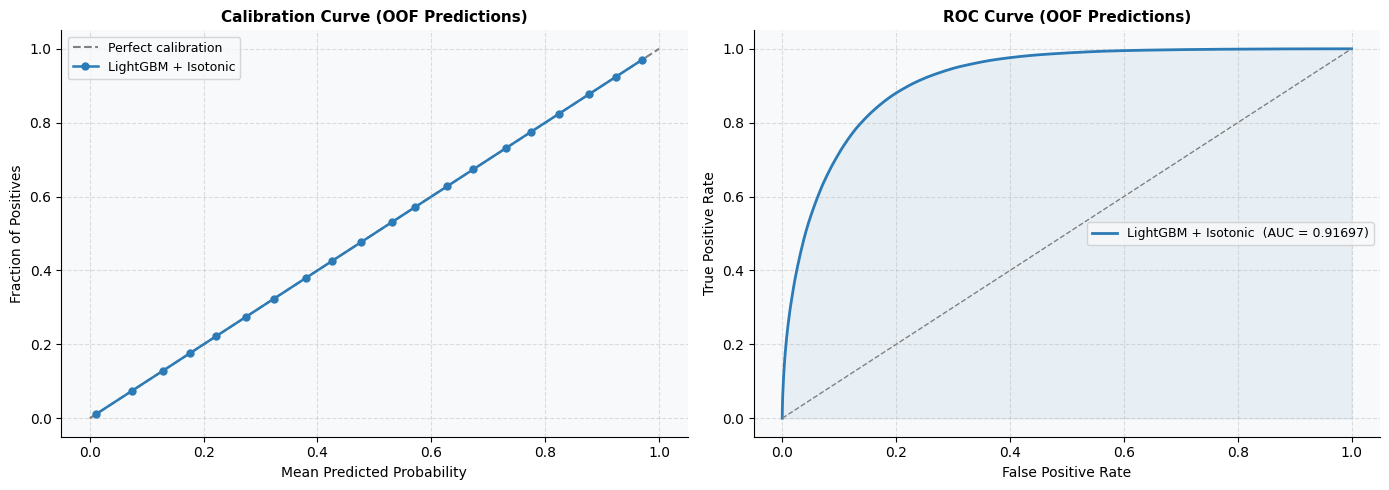

In [9]:
# Figure 4: Calibration curve + ROC curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Calibration curve
frac_pos, mean_pred = calibration_curve(y, oof_preds, n_bins=20, strategy='uniform')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
axes[0].plot(mean_pred, frac_pos, 'o-', color=PALETTE[0], markersize=5,
             linewidth=1.8, label='LightGBM + Isotonic')
axes[0].set_xlabel('Mean Predicted Probability')
axes[0].set_ylabel('Fraction of Positives')
axes[0].set_title('Calibration Curve (OOF Predictions)', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)

# ROC curve
fpr, tpr, _ = roc_curve(y, oof_preds)
auc_val = roc_auc_score(y, oof_preds)
axes[1].plot(fpr, tpr, color=PALETTE[0], linewidth=2,
             label=f'LightGBM + Isotonic  (AUC = {auc_val:.5f})')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1)
axes[1].fill_between(fpr, tpr, alpha=0.08, color=PALETTE[0])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve (OOF Predictions)', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('04_calibration_roc.png', dpi=150, bbox_inches='tight')
plt.show()

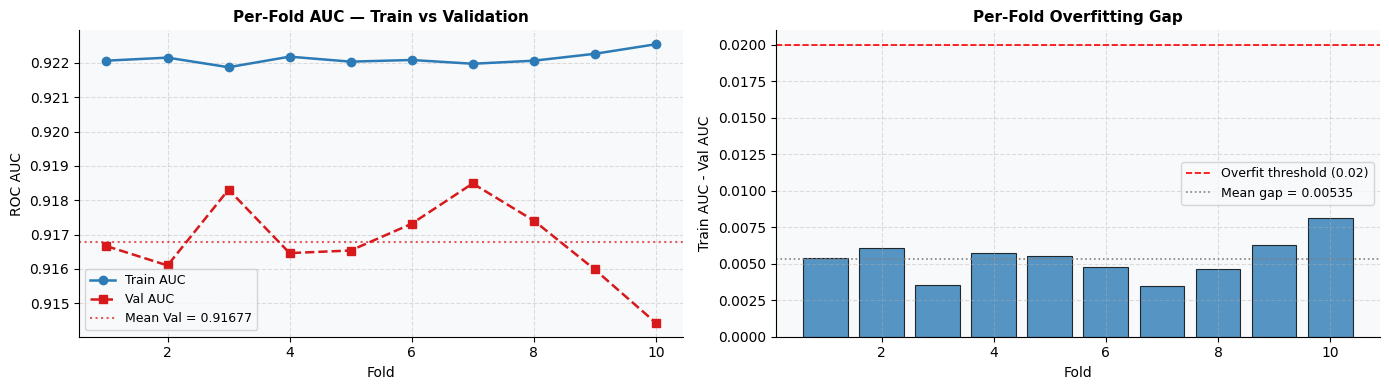

In [10]:
# Figure 5: Per-fold AUC and overfitting gap
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

folds = np.arange(1, N_FOLDS + 1)
axes[0].plot(folds, train_auc_scores, 'o-', color=PALETTE[0], linewidth=1.8, label='Train AUC')
axes[0].plot(folds, val_auc_scores,   's--', color=PALETTE[1], linewidth=1.8, label='Val AUC')
axes[0].axhline(np.mean(val_auc_scores), color=PALETTE[1], linestyle=':',
                alpha=0.7, label=f'Mean Val = {np.mean(val_auc_scores):.5f}')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('ROC AUC')
axes[0].set_title('Per-Fold AUC — Train vs Validation', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)

gaps = np.array(train_auc_scores) - np.array(val_auc_scores)
axes[1].bar(folds, gaps,
            color=[PALETTE[1] if g > 0.02 else PALETTE[0] for g in gaps],
            alpha=0.8, edgecolor='black', linewidth=0.8)
axes[1].axhline(0.02, color='red', linestyle='--', linewidth=1.2, label='Overfit threshold (0.02)')
axes[1].axhline(np.mean(gaps), color='gray', linestyle=':',
                linewidth=1.2, label=f'Mean gap = {np.mean(gaps):.5f}')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('Train AUC - Val AUC')
axes[1].set_title('Per-Fold Overfitting Gap', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('05_fold_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Feature Importance Analysis

LightGBM provides three importance metrics. Understanding which to use and when is important for avoiding misinterpretation:

**`gain`** measures the total reduction in loss contributed by all splits on a given feature across all trees. This is the most meaningful measure of a feature's contribution to model accuracy and is the recommended default for feature selection decisions.

**`split`** counts how many times a feature was used to split a node across all trees. High split count can indicate a feature is used frequently for shallow refinement, but it does not measure how much each split actually reduced the loss — a feature can be split-heavy but gain-light.

For feature importance ranking and feature selection, gain is the appropriate metric. SHAP (Shapley values) provides per-sample attribution and is the gold standard for interpretability, but is computationally expensive. For the purposes of this notebook, gain-based importance is reported on a model fit to the full training set to produce stable estimates.

Top 20 features by gain importance:
             feature  importance
        TotalCharges        9195
   Charge_Difference        8236
      MonthlyCharges        8123
   Avg_Monthly_Spent        7110
              tenure        5750
      Expected_Total        5075
            Contract        1901
       PaymentMethod        1519
Total_Extra_Services        1466
       MultipleLines         976
    PaperlessBilling         896
          Dependents         848
      OnlineSecurity         705
              gender         679
             Partner         671
     InternetService         640
       SeniorCitizen         600
         StreamingTV         596
     StreamingMovies         575
         TechSupport         554


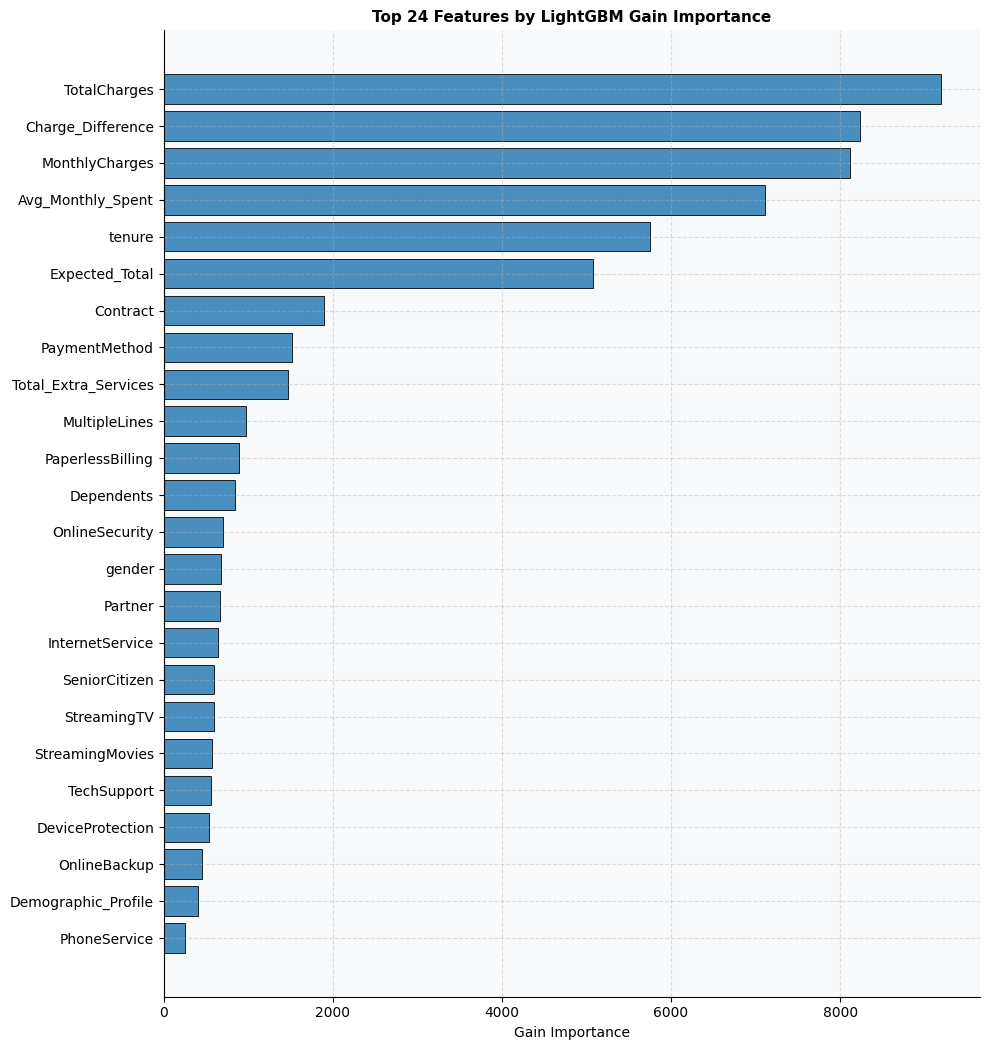

13084

In [11]:
# Refit a single full-data model for stable importance estimates
final_model = lgb.LGBMClassifier(**LGBM_PARAMS)
final_model.fit(X, y, callbacks=[lgb.log_evaluation(period=-1)])

importance_df = pd.DataFrame({
    'feature':    X.columns,
    'importance': final_model.feature_importances_,
}).sort_values('importance', ascending=False).reset_index(drop=True)

print('Top 20 features by gain importance:')
print(importance_df.head(20).to_string(index=False))

# Plot top 25
top_n = min(25, len(importance_df))
fig, ax = plt.subplots(figsize=(10, top_n * 0.4 + 1))
ax.barh(
    importance_df['feature'].iloc[:top_n][::-1],
    importance_df['importance'].iloc[:top_n][::-1],
    color=PALETTE[0], alpha=0.85, edgecolor='black', linewidth=0.7
)
ax.set_xlabel('Gain Importance')
ax.set_title(f'Top {top_n} Features by LightGBM Gain Importance',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('06_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

del final_model
gc.collect()

## 8. Submission

The test set predictions are the simple average of calibrated probability outputs across all 10 folds. Averaging across folds rather than using a single model's predictions reduces variance: each fold's model was trained on a different 90% of the training data, so their predictions represent 10 independent estimates of the posterior churn probability. The average of independent estimators with comparable bias is a more stable estimator than any individual one — this is the core principle of bagging.

The submission column contains raw probability values, not binary class labels, matching the Kaggle evaluation metric (ROC AUC) which evaluates the full probability ranking rather than a single threshold decision.

A calibration sanity check is included: the mean predicted probability on the test set should be close to the training set churn rate if the model is well-calibrated. Large deviations (>5 percentage points) indicate systematic miscalibration and should prompt investigation.

In [12]:
submission = pd.DataFrame({
    ID_COL: test_ids,
    TARGET: test_preds,
})

output_path = 'submission_lgbm_churn.csv'
submission.to_csv(output_path, index=False)

print(f'Submission saved : {output_path}')
print(f'Shape            : {submission.shape}')
print(f'Prediction range : [{test_preds.min():.6f}, {test_preds.max():.6f}]')
print(f'Mean prediction  : {test_preds.mean():.6f}  (train churn rate: {y.mean():.6f})')
print(f'Calibration gap  : {abs(test_preds.mean() - y.mean()):.6f}')
print()
print('Sample output:')
print(submission.head(10).to_string(index=False))

Submission saved : submission_lgbm_churn.csv
Shape            : (254655, 2)
Prediction range : [0.000000, 0.998214]
Mean prediction  : 0.218135  (train churn rate: 0.225208)
Calibration gap  : 0.007072

Sample output:
    id    Churn
594194 0.078072
594195 0.000201
594196 0.106933
594197 0.003352
594198 0.523796
594199 0.184573
594200 0.903647
594201 0.002711
594202 0.036376
594203 0.318732
